In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings('ignore')

### Data Loading & Cleaning

In [2]:
def load_and_clean_pro(filepath):
    df = pd.read_csv(filepath)
    
   # Standardizing district names and removing hidden spaces
    df['district'] = df['district'].str.strip().str.capitalize()

    # 2. Use a "Contains" logic to catch homoglyphs
    df.loc[df['district'].str.startswith('Bur', na=False), 'district'] = 'Burera'
    df.loc[df['district'].str.startswith('Nya', na=False), 'district'] = 'Nyabihu'
    df.loc[df['district'].str.startswith('Gak', na=False), 'district'] = 'Gakenke'
    df.loc[df['district'].str.startswith('Mus', na=False), 'district'] = 'Musanze'
    df.loc[df['district'].str.startswith('Rul', na=False), 'district'] = 'Rulindo'
    print(f"Cleaned Districts: {df['district'].unique()}")

    # Fioxing Swapped coordinate
    mask = df['latitude'] > df['longitude']
    df.loc[mask, ['latitude', 'longitude']] = df.loc[mask, ['longitude', 'latitude']].values
    
    # Negative usage correction
    usage_cols = [f'usage_month_{i}' for i in range(1, 7)]
    df[usage_cols] = df[usage_cols].mask(df[usage_cols] < 0)
    
    # District-level imputation
    geo_cols = [
        'elevation_m', 'latitude', 'longitude',
        'distance_to_market_km', 'household_size'
    ]
    
    for col in geo_cols:
        df[col] = df[col].fillna(
            df.groupby('district')[col].transform('median')
        )
    
    # Outlier clipping for baseline fuel usage
    upper_bound = df['baseline_fuel_kg_person_week'].quantile(0.99)
    df['baseline_fuel_kg_person_week'] = df[
        'baseline_fuel_kg_person_week'
    ].clip(upper=upper_bound)
    

    # Target variable creation
    df['weekly_baseline_hh'] = (
        df['baseline_fuel_kg_person_week'] * df['household_size']
    )
    
    df['avg_weekly_usage'] = df[usage_cols].mean(axis=1)
    
    df['pct_reduction'] = (
        (df['weekly_baseline_hh'] - df['avg_weekly_usage']) /
        df['weekly_baseline_hh']
    )
    
    df['low_adoption'] = (df['pct_reduction'] < 0.30).astype(int)
    
    df = df.dropna(subset=['low_adoption'])
    
    return df


### Feature Engineering

In [3]:
def engineer_features_pro(df):
    # Market accessibility interaction
    df['market_climb_index'] = (
        df['distance_to_market_km'] * (df['elevation_m'] / 1000)
    )
    
    # Fuel intensity proxy
    df['fuel_need_per_capita'] = df['baseline_fuel_kg_person_week']
    
    # Seasonality
    df['distribution_date'] = pd.to_datetime(
        df['distribution_date'], dayfirst=True
    )
    df['dist_month'] = df['distribution_date'].dt.month
    
    df['is_rainy_season'] = df['dist_month'].isin(
        [3, 4, 5, 9, 10, 11, 12]
    ).astype(int)
    
    # Relative remoteness 
    district_centers = df.groupby('district')[['latitude', 'longitude']].transform('mean')
    
    df['relative_remoteness'] = np.sqrt(
        (df['latitude'] - district_centers['latitude'])**2 +
        (df['longitude'] - district_centers['longitude'])**2
    )
    
    return df


### Loading & Preparing the Dataset

In [4]:
data = load_and_clean_pro("delagua_stove_data.csv")
data = engineer_features_pro(data)

data.head()


Cleaned Districts: ['Musanze' 'Burera' 'Gakenke' 'Rulindo' 'Nyabihu']


,household_id,district,latitude,longitude,distribution_date,household_size,baseline_fuel_kg_person_week,distance_to_market_km,elevation_m,usage_month_1,...,usage_month_6,weekly_baseline_hh,avg_weekly_usage,pct_reduction,low_adoption,market_climb_index,fuel_need_per_capita,dist_month,is_rainy_season,relative_remoteness
0,HH-02216,Musanze,-1.470711,29.595319,2023-11-04,4.0,8.2,6.6,2084,13.5,...,11.1,32.8,13.416667,0.590955,0,13.7544,8.2,11,1,0.015050
1,HH-02583,Burera,-1.452974,29.765346,2024-01-21,5.0,12.4,7.9,2003,28.9,...,26.7,62.0,30.720000,0.504516,0,15.8237,12.4,1,0,0.078578
2,HH-01663,Gakenke,-1.652503,29.764647,2024-03-30,7.0,9.5,8.4,1956,55.2,...,54.0,66.5,55.016667,0.172682,1,16.4304,9.5,3,1,0.027685
3,HH-03028,Burera,-1.434321,29.739065,2023-04-18,5.0,9.6,3.2,1866,51.9,...,37.2,48.0,44.350000,0.076042,1,5.9712,9.6,4,1,0.050869
4,HH-04344,Rulindo,-1.799681,29.958393,2024-02-10,5.0,10.9,0.7,1887,26.8,...,17.9,54.5,24.366667,0.552905,0,1.3209,10.9,2,0,0.065385


### Modeling Pipeline

In [5]:
features = [
    'district', 'latitude', 'longitude', 'household_size',
    'baseline_fuel_kg_person_week', 'distance_to_market_km',
    'elevation_m', 'market_climb_index', 'fuel_need_per_capita',
    'is_rainy_season', 'relative_remoteness'
]

X = data[features].copy()
y = data['low_adoption']

# Encode districts
le = LabelEncoder()
X['district'] = le.fit_transform(X['district'])

model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Mean CV ROC-AUC: 0.6383 (+/- 0.0459)


### Train-Test Split & Final Model Fit

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.63      0.62      0.62       843
           1       0.58      0.59      0.59       757

    accuracy                           0.61      1600
   macro avg       0.61      0.61      0.61      1600
weighted avg       0.61      0.61      0.61      1600

Test ROC-AUC: 0.639792149506935


### Permutation Feature Importance

In [7]:
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head(10)


,feature,importance
7,market_climb_index,0.026937
4,baseline_fuel_kg_person_week,0.018500
3,household_size,0.018437
0,district,0.013062
2,longitude,0.010000
5,distance_to_market_km,0.009937
1,latitude,0.009875
6,elevation_m,0.008812
10,relative_remoteness,0.006125
8,fuel_need_per_capita,0.000000


### Spatial Risk Summary (District-Level)

In [8]:
district_risk = (
    data.groupby("district")["low_adoption"]
    .mean()
    .sort_values(ascending=False)
)

district_risk


district
Gakenke    0.617672
Nyabihu    0.538717
Burera     0.529290
Musanze    0.395522
Rulindo    0.336551
Name: low_adoption, dtype: float64

### Adoption Insight Visualisations

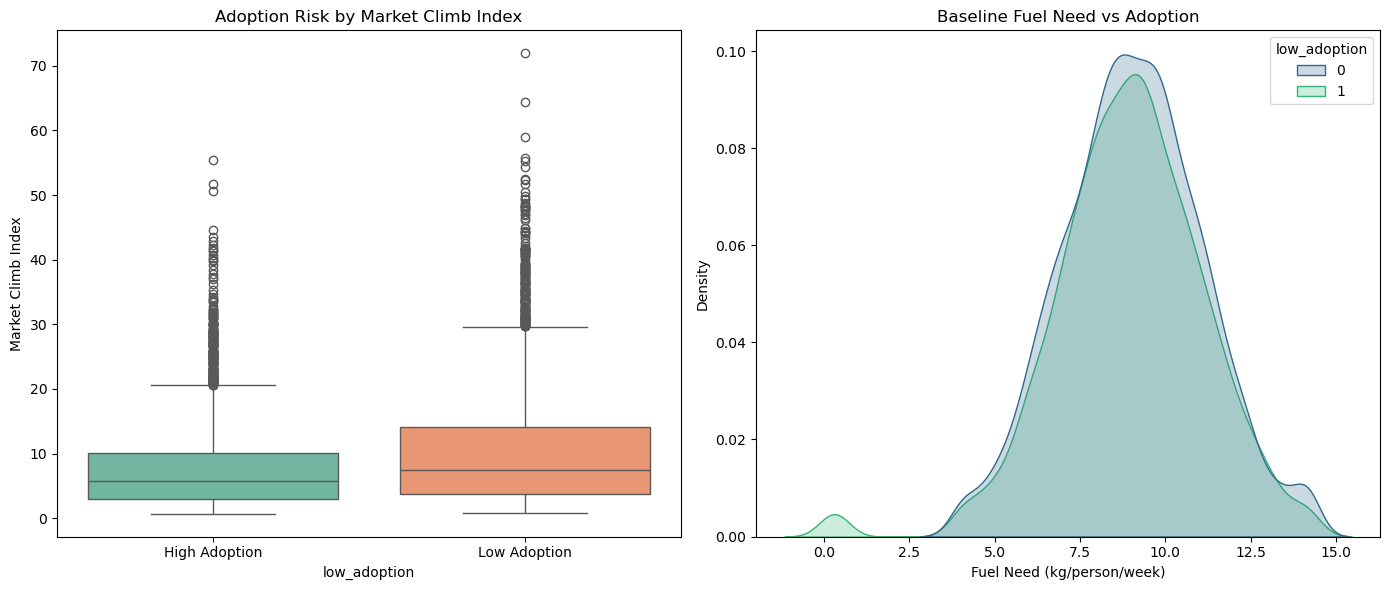

In [9]:
plt.figure(figsize=(14, 6))

# Market climb index
plt.subplot(1, 2, 1)
sns.boxplot(
    x="low_adoption",
    y="market_climb_index",
    data=data,
    palette="Set2"
)
plt.title("Adoption Risk by Market Climb Index")
plt.xticks([0, 1], ["High Adoption", "Low Adoption"])
plt.ylabel("Market Climb Index")

# Fuel need distribution
plt.subplot(1, 2, 2)
sns.kdeplot(
    data=data,
    x="fuel_need_per_capita",
    hue="low_adoption",
    fill=True,
    palette="viridis"
)
plt.title("Baseline Fuel Need vs Adoption")
plt.xlabel("Fuel Need (kg/person/week)")

plt.tight_layout()
plt.show()


Calculating feature importance for dashboard...


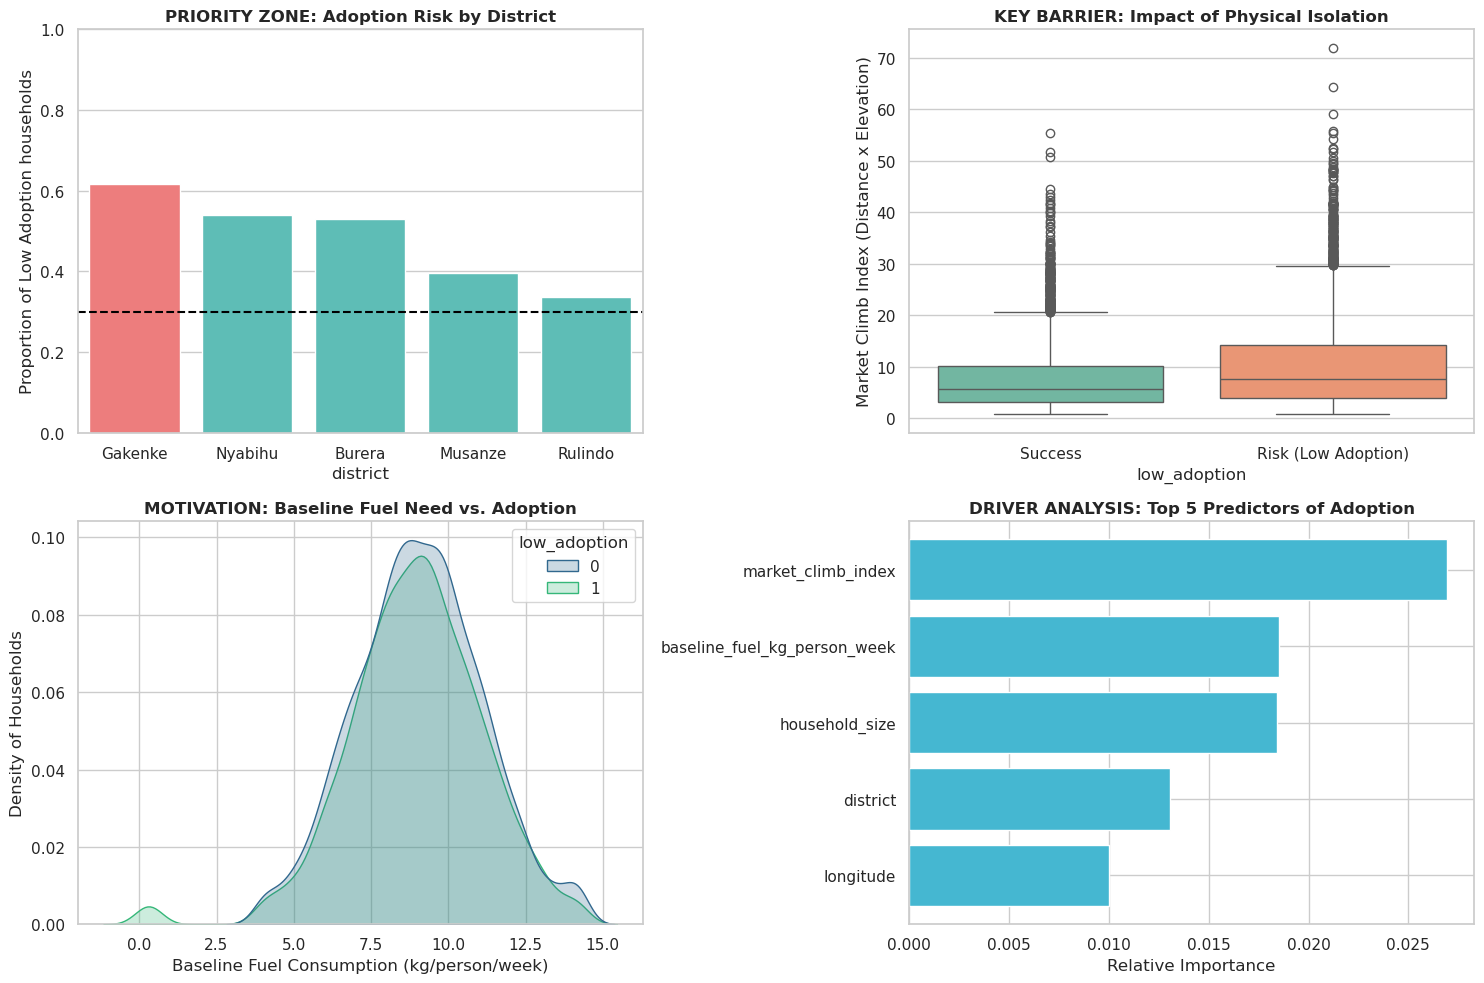

Exception ignored in: <function ResourceTracker.__del__ at 0x7e56b65a72e0>
Traceback (most recent call last):
  File "/home/emmanuel/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/emmanuel/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/emmanuel/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x73f4d5b8b2e0>
Traceback (most recent call last):
  File "/home/emmanuel/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/emmanuel/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/emmanuel/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function Resour

In [ ]:
def run_management_dashboard(model, X_test, y_test, df):
    print("Calculating feature importance for dashboard...")
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    
    # Set style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(15, 10))
    
    # CHART 1: Risk by District
    plt.subplot(2, 2, 1)
    district_risk = df.groupby('district')['low_adoption'].mean().sort_values(ascending=False)
    colors = ['#ff6b6b' if x == district_risk.max() else '#4ecdc4' for x in district_risk.values]
    sns.barplot(x=district_risk.index, y=district_risk.values, palette=colors)
    plt.axhline(y=0.3, color='black', linestyle='--', label='Target Threshold (30%)')
    plt.title('PRIORITY ZONE: Adoption Risk by District', fontsize=12, fontweight='bold')
    plt.ylabel('Proportion of Low Adoption households')
    plt.ylim(0, 1)
    
    # CHART 2: Isolation/Market Climb
    plt.subplot(2, 2, 2)
    sns.boxplot(x='low_adoption', y='market_climb_index', data=df, palette='Set2')
    plt.title('KEY BARRIER: Impact of Physical Isolation', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['Success', 'Risk (Low Adoption)'])
    plt.ylabel('Market Climb Index (Distance x Elevation)')
    
    # CHART 3: Economic Motivation
    plt.subplot(2, 2, 3)
    sns.kdeplot(data=df, x='fuel_need_per_capita', hue='low_adoption', fill=True, palette='viridis')
    plt.title('MOTIVATION: Baseline Fuel Need vs. Adoption', fontsize=12, fontweight='bold')
    plt.xlabel('Baseline Fuel Consumption (kg/person/week)')
    plt.ylabel('Density of Households')
    
    # CHART 4: Top Feature Importance
    plt.subplot(2, 2, 4)
    sorted_idx = result.importances_mean.argsort()[-5:]
    plt.barh(X_test.columns[sorted_idx], result.importances_mean[sorted_idx], color='#45b7d1')
    plt.title('DRIVER ANALYSIS: Top 5 Predictors of Adoption', fontsize=12, fontweight='bold')
    plt.xlabel('Relative Importance')
    
    plt.tight_layout()
    plt.show()

run_management_dashboard(model, X_test, y_test, data)